# Ejercicio 1 - Mezcla de Fertilizante
A petición del profesor, se realiza esta implementación usando PuLP.

In [2]:
import pulp

prob = pulp.LpProblem("Max_Fer", pulp.LpMaximize)

#Definir las variables de decisión (Continuas y >= 0)
f1 = pulp.LpVariable("F1_ton", lowBound=0, cat='Continuous')
f2 = pulp.LpVariable("F2_ton", lowBound=0, cat='Continuous')

#Función Objetivo
prob += 180 * f1 + 220 * f2, "Ganancia"

#Restricciones
prob += 3 * f1 + 4 * f2 <= 120, "Disponibilidad_Compuesto_A"
prob += 2 * f1 + 1 * f2 <= 80,  "Disponibilidad_Compuesto_B"
prob += 5 * f1 + 3 * f2 <= 150, "Disponibilidad_Compuesto_C"

#Solución
status = prob.solve()

#Mostrar resultados
print(f"Estado del optimizador: {pulp.LpStatus[status]}")
print(f"Producción óptima de Fertilizante F1 (f1): {pulp.value(f1)} toneladas")
print(f"Producción óptima de Fertilizante F2 (f2): {pulp.value(f2)} toneladas")
print(f"Ganancia Total Máxima: ${pulp.value(prob.objective)}")

Estado del optimizador: Optimal
Producción óptima de Fertilizante F1 (f1): 21.818182 toneladas
Producción óptima de Fertilizante F2 (f2): 13.636364 toneladas
Ganancia Total Máxima: $6927.27284


# Ejercicio 2 - Producción semanal de una fábrica

Se implementa el modelo para calcular la producción a las n semanas. La funciòn utiliza un bucle iterativo.

In [4]:
def simular_produccion(semanas_a_simular):
    #Condiciones iniciales
    S = 200
    M = 80
    for n in range(1, semanas_a_simular + 1):
        sig_S = 0.6 * S + 0.2 * M + 40
        sig_M = 0.1 * S + 0.5 * M + 20
        S = sig_S
        M = sig_M
    return f"Semana {n}: Sillas = {S:.1f}, Mesas = {M:.1f}"

def calcular_equilibrio():
    A = np.array([[0.4, -0.2], [-0.1, 0.5]])
    b = np.array([40, 20])
    equilibrio = np.linalg.solve(A, b)

    print(f"Si la tendencia continúa, la producción se estabilizará en:")
    print(f"Sillas (S*) = {equilibrio[0]:.1f}")
    print(f"Mesas (M*) = {equilibrio[1]:.1f}")


calcular_equilibrio()
print(simular_produccion(1))
print(simular_produccion(2))
print(simular_produccion(160))

Si la tendencia continúa, la producción se estabilizará en:
Sillas (S*) = 133.3
Mesas (M*) = 66.7
Semana 1: Sillas = 176.0, Mesas = 80.0
Semana 2: Sillas = 161.6, Mesas = 77.6
Semana 160: Sillas = 133.3, Mesas = 66.7


# Ejercicio 3 - Epidemia en una ciudad

Solucion al problema utilizando derivacion e integracion de SciPy para EDOs. También se realizó una gráfica para mostrar el crecimiento de la pandemia y el punto de equilibrio.

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_619/1242469133.py:34: SyntaxWarning: invalid escape sequence '\s'
  ax.axhline(y=20000/3, color=color_equilibrio, linestyle='--', linewidth=2, alpha=0.7, label='Equilibrio Teórico ($\sim$6667)')


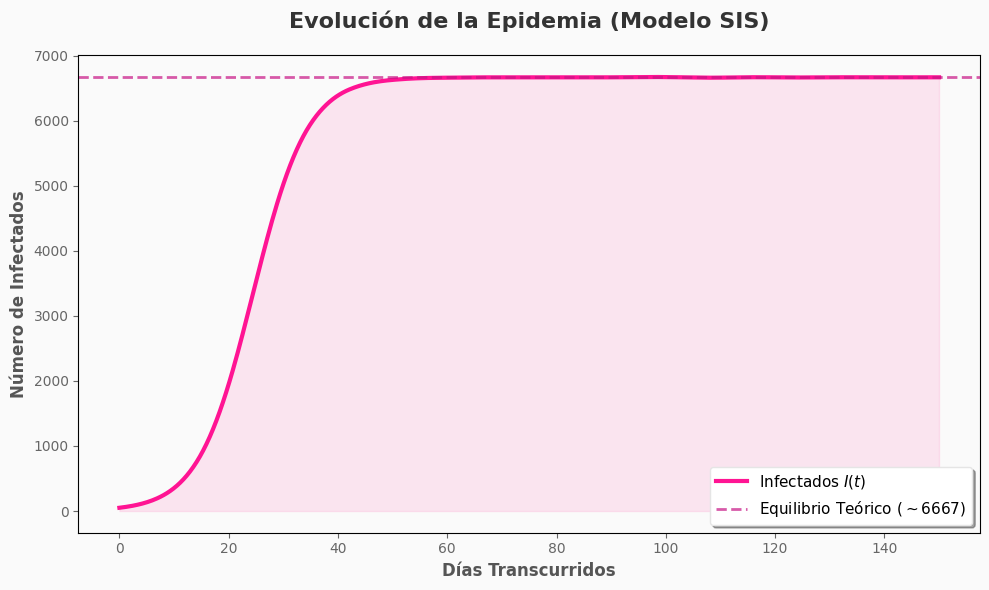

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Parámetros del modelo
beta = 0.00003
gamma = 0.1
N = 10000
I0 = 50

# 2. EDO
def dI_dt(t, I):
    return beta * (N - I) * I - gamma * I

# 3. Simulación
t_span = (0, 150)
t_eval = np.linspace(t_span[0], t_span[1], 500)
solucion = solve_ivp(dI_dt, t_span, [I0], t_eval=t_eval)

tiempo = solucion.t
infectados = solucion.y[0]


# Grafica
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
color_linea = '#FF1493'
color_relleno = '#FF69B4'
color_equilibrio = '#C71585'

# Elementos en la grafica
ax.plot(tiempo, infectados, label='Infectados $I(t)$', color=color_linea, linewidth=3)
ax.fill_between(tiempo, infectados, color=color_relleno, alpha=0.15)
ax.axhline(y=20000/3, color=color_equilibrio, linestyle='--', linewidth=2, alpha=0.7, label='Equilibrio Teórico ($\sim$6667)')
ax.set_title('Evolución de la Epidemia (Modelo SIS)', fontsize=16, fontweight='bold', color='#333333', pad=20)
ax.set_xlabel('Días Transcurridos', fontsize=12, fontweight='bold', color='#555555')
ax.set_ylabel('Número de Infectados', fontsize=12, fontweight='bold', color='#555555')
ax.tick_params(colors='#666666', labelsize=10)
ax.legend(frameon=True, facecolor='white', edgecolor='#E5E5E5', fontsize=11, loc='lower right', shadow=True)

# Ajuste de margenes porque se sale
plt.tight_layout()
plt.show()

# Ejercicio 4 - Modelo logístico de pesca


In [7]:
import numpy as np

def simular_laguna(años):
    K = 1000
    H = 80
    r = 0.4
    P = 400  # Población inicial
    print(f"Año 0: Población = {P}")
    for n in range(1, años + 1):
        crecimiento = r * P * (1 - (P / K))
        nuevo_P = P + crecimiento - H
        if nuevo_P < 0:
            print(f"Año {n}: La población se extinguió (P < 0).")
            break
        P = nuevo_P

        print(f"Año {n}: Población = {P:.1f}")

def calcular_equilibrios_pesca():
    coeficientes = [1, -1000, 200000]
    puntos_equilibrio = np.roots(coeficientes)

    print(f"\nEquilibrio Estable (Capacidad con pesca): {puntos_equilibrio[0]:.1f} peces")
    print(f"Equilibrio Inestable (Punto de no retorno): {puntos_equilibrio[1]:.1f} peces")

simular_laguna(5)
calcular_equilibrios_pesca()

Año 0: Población = 400
Año 1: Población = 416.0
Año 2: Población = 433.2
Año 3: Población = 451.4
Año 4: Población = 470.4
Año 5: Población = 490.1

Equilibrio Estable (Capacidad con pesca): 723.6 peces
Equilibrio Inestable (Punto de no retorno): 276.4 peces
